<a href="https://colab.research.google.com/github/JessieGuo1/MATH5881-Tutorials/blob/main/tutorials/Week10_Lab%2C_Solutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 10 Lab: VAE versus DDPM on an 8-Gaussian Toy Dataset

This Lab compares a Variational Autoencoder (VAE) and a Denoising Diffusion Probabilistic Model (DDPM) on a simple 2D generation task: learning samples from 8 Gaussian components arranged on a circle (Gaussian mixture).

The purpose of this notebook is to make a well-known qualitative difference visible in a fast experiment:

* a VAE with a simple Gaussian latent prior and a restrictive decoder can produce under-dispersed or overly smoothed samples;
* a DDPM can often preserve the support and spread of a multimodal distribution more faithfully, because it generates by many small denoising steps rather than a single decode from a latent vector.

You'll see that we use 5,000 training samples and generate 5,000 samples from each model, so the experiment should run quickly on Colab.

The DDPM is built largely from the implementation here: https://github.com/AlbertoParravicini/ddpm-from-scratch/

## Structure

The notebook is split into:

* Step 1: generate and visualise the 8-Gaussian dataset;
* Step 2: define comparison metrics for generated samples;
* Step 3: implement and train a VAE;
* Step 4: implement and train a DDPM;
* Step 5: compare samples and variance estimates.

In [1]:
# Import main libraries
import math
import os
import random
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

%matplotlib inline

In [2]:
def seed_everything(seed=20211201):
    # Make the main sources of randomness deterministic.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def get_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def save_state(model, optimizer, filename):
    torch.save({
        'model': model.state_dict(),
        'optimizer': optimizer.state_dict(),
    }, filename)


def load_state(model, optimizer, filename, map_location=None):
    state = torch.load(filename, map_location=map_location)
    model.load_state_dict(state['model'])
    if optimizer is not None and 'optimizer' in state:
        optimizer.load_state_dict(state['optimizer'])
    return model

seed_everything()
device = get_device()
print('Using device:', device)

Using device: cpu


# Step 1. Generate and visualise data

Here the "data" distribution is 8 isotropic Gaussian components equally spaced on a circle. This is a common toy benchmark for generative models because the target distribution is simple enough to visualise but still clearly multimodal.

The default settings are:

* 8 components;
* 5,000 training samples;
* component means on a circle of radius 2;
* component standard deviation 0.08.

In [3]:
def make_8_gaussians(n_samples=5000, radius=2.0, std=0.08, seed=0):
    # Generate the standard 8-Gaussians-on-a-circle toy dataset.
    rng = np.random.default_rng(seed)
    angles = np.linspace(0, 2 * np.pi, 8, endpoint=False)
    centers = np.stack([radius * np.cos(angles), radius * np.sin(angles)], axis=1).astype(np.float32)
    labels = rng.integers(0, 8, size=n_samples)
    noise = rng.normal(loc=0.0, scale=std, size=(n_samples, 2)).astype(np.float32)
    x = centers[labels] + noise
    return x.astype(np.float32), labels.astype(np.int64), centers


def plot_2d_samples(samples, centers=None, title=None, ax=None, lim=2.8, alpha=0.35, s=8):
    # Helper function for plotting 2D generated samples.
    if isinstance(samples, torch.Tensor):
        samples = samples.detach().cpu().numpy()
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(samples[:, 0], samples[:, 1], s=s, alpha=alpha)
    if centers is not None:
        ax.scatter(centers[:, 0], centers[:, 1], marker='x', s=90, linewidths=2)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.25)
    if title is not None:
        ax.set_title(title)
    return ax

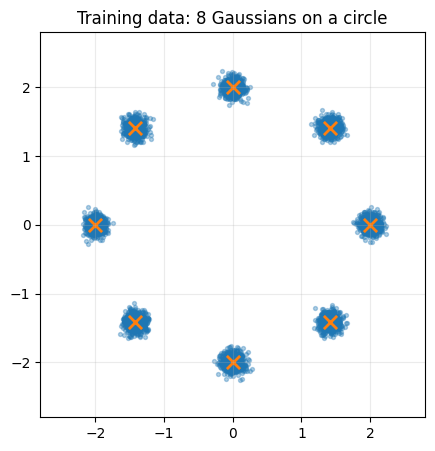

Training data shape: torch.Size([5000, 2])
Number of batches per epoch: 20


In [4]:
# Dataset settings from the discussion
n_train = 5000
n_generate = 5000
radius = 2.0
component_std = 0.08
batch_size = 256

x_train_np, y_train_np, centers_np = make_8_gaussians(
    n_samples=n_train,
    radius=radius,
    std=component_std,
    seed=20211201,
)

x_train = torch.tensor(x_train_np, dtype=torch.float32)
train_loader = DataLoader(TensorDataset(x_train), batch_size=batch_size, shuffle=True, drop_last=False)

fig, ax = plt.subplots(figsize=(5, 5))
plot_2d_samples(x_train_np, centers_np, title='Training data: 8 Gaussians on a circle', ax=ax)
plt.show()

print('Training data shape:', x_train.shape)
print('Number of batches per epoch:', len(train_loader))

# Step 2. Define quantitative comparison metrics

We'll compute some metrics to quantify the performance of the two methods.  Although the differences will be visually clear, such metrics are useful when working in higher dimensions and visualisation is more challenging.

* **covariance trace**: total variance in the generated samples;
* **variance ratio**: generated covariance trace divided by true covariance trace;
* **radial mean and radial standard deviation**: whether samples lie at approximately the correct distance from the origin;
* **component coverage**: whether generated samples reach all 8 modes;
* **mean squared distance to nearest component centre**: a rough within-mode spread diagnostic.

For this Lab, the main quantity of interest is the **variance ratio**. A value below 1 indicates underestimation of total sample variance.

In [5]:
def nearest_center_stats(samples, centers):
    # Assign samples to nearest true centre and compute component statistics.
    if isinstance(samples, torch.Tensor):
        samples = samples.detach().cpu().numpy()
    samples = np.asarray(samples)
    centers = np.asarray(centers)
    diff = samples[:, None, :] - centers[None, :, :]
    dist2 = np.sum(diff ** 2, axis=-1)
    assignment = np.argmin(dist2, axis=1)
    nearest_dist2 = dist2[np.arange(len(samples)), assignment]
    counts = np.bincount(assignment, minlength=len(centers))
    return assignment, counts, nearest_dist2


def sample_summary(samples, centers, true_samples=None, name='model'):
    # Summarise generated samples using simple 2D diagnostics.
    if isinstance(samples, torch.Tensor):
        samples = samples.detach().cpu().numpy()
    samples = np.asarray(samples)
    cov = np.cov(samples.T)
    cov_trace = float(np.trace(cov))
    radius_values = np.sqrt(np.sum(samples ** 2, axis=1))
    assignment, counts, nearest_dist2 = nearest_center_stats(samples, centers)

    summary = {
        'model': name,
        'cov_trace': cov_trace,
        'radial_mean': float(radius_values.mean()),
        'radial_std': float(radius_values.std()),
        'nearest_center_mse': float(nearest_dist2.mean()),
        'covered_components': int(np.sum(counts > 0)),
        'min_component_count': int(counts.min()),
        'max_component_count': int(counts.max()),
    }

    if true_samples is not None:
        true_cov_trace = float(np.trace(np.cov(np.asarray(true_samples).T)))
        summary['true_cov_trace'] = true_cov_trace
        summary['variance_ratio'] = cov_trace / true_cov_trace

    return summary


def print_summary_table(summaries):
    keys = [
        'model', 'cov_trace', 'variance_ratio', 'radial_mean', 'radial_std',
        'nearest_center_mse', 'covered_components', 'min_component_count', 'max_component_count'
    ]
    print(' | '.join(keys))
    print(' | '.join(['---'] * len(keys)))
    for row in summaries:
        values = []
        for key in keys:
            val = row.get(key, '')
            if isinstance(val, float):
                values.append(f'{val:.4f}')
            else:
                values.append(str(val))
        print(' | '.join(values))

In [6]:
true_summary = sample_summary(x_train_np, centers_np, true_samples=x_train_np, name='True data')
print_summary_table([true_summary])

model | cov_trace | variance_ratio | radial_mean | radial_std | nearest_center_mse | covered_components | min_component_count | max_component_count
--- | --- | --- | --- | --- | --- | --- | --- | ---
True data | 4.0072 | 1.0000 | 2.0000 | 0.0795 | 0.0128 | 8 | 579 | 670


# Step 3. VAE implementation

The VAE below uses the standard ingredients:

1. an encoder that maps a 2D point to a Gaussian approximate posterior $q_\phi(z \mid x)$;
2. the reparameterisation trick $z = \mu + \sigma \epsilon$;
3. a decoder that maps $z$ back to a 2D point;
4. the ELBO loss, implemented as reconstruction error plus KL divergence.

To make the under-dispersion effect visible, the default VAE is intentionally kept simple: it uses a **1D latent variable** and a modest KL weight. You can set `vae_latent_dim = 2` or reduce `beta_vae` if you want to make the VAE more expressive.

In [7]:
class VAE(nn.Module):
    def __init__(self, data_dim=2, latent_dim=1, hidden_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(data_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, data_dim),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterise(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar


def vae_loss(recon_x, x, mu, logvar, beta=1.0):
    # Mean squared error corresponds to a Gaussian decoder with fixed variance,
    # up to an additive and multiplicative constant.
    recon = F.mse_loss(recon_x, x, reduction='sum') / x.shape[0]
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.shape[0]
    return recon + beta * kl, recon, kl

### **Exercise 1**

Why might a simple VAE underestimate sample variance on this dataset?

<details><summary><a>Answer (click)</a></summary>
The VAE samples by drawing from a simple Gaussian prior and decoding once. The KL term encourages the aggregated latent representation to remain close to a simple Gaussian, while the decoder is asked to map this simple latent distribution to a multimodal ring of points. With limited capacity or a tight bottleneck, the decoder may produce conservative samples that occupy a smaller or smoother region than the true distribution.
</details>



In [8]:
def train_vae(model, train_loader, epochs=200, lr=1e-3, beta=2.0, device='cpu'):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {'loss': [], 'recon': [], 'kl': []}

    for epoch in tqdm(range(epochs), desc='Training VAE'):
        model.train()
        loss_sum = recon_sum = kl_sum = 0.0
        n_seen = 0
        for (x,) in train_loader:
            x = x.to(device)
            optimizer.zero_grad()
            recon, mu, logvar = model(x)
            loss, recon_loss, kl_loss = vae_loss(recon, x, mu, logvar, beta=beta)
            loss.backward()
            optimizer.step()

            batch_n = x.shape[0]
            loss_sum += loss.item() * batch_n
            recon_sum += recon_loss.item() * batch_n
            kl_sum += kl_loss.item() * batch_n
            n_seen += batch_n

        history['loss'].append(loss_sum / n_seen)
        history['recon'].append(recon_sum / n_seen)
        history['kl'].append(kl_sum / n_seen)

    return model, optimizer, history


def sample_vae(model, n_samples=5000, latent_dim=1, device='cpu'):
    model.eval()
    with torch.no_grad():
        z = torch.randn(n_samples, latent_dim, device=device)
        samples = model.decode(z)
    return samples.detach().cpu()

In [9]:
# VAE training settings
vae_latent_dim = 1
vae_hidden_dim = 64
vae_epochs = 200
beta_vae = 2.0

vae = VAE(data_dim=2, latent_dim=vae_latent_dim, hidden_dim=vae_hidden_dim)
print(vae)
print('Number of trainable parameters:', count_parameters(vae))

# Run this cell to train the VAE.
vae, vae_optimizer, vae_history = train_vae(
    vae,
    train_loader,
    epochs=vae_epochs,
    lr=1e-3,
    beta=beta_vae,
    device=device,
)


VAE(
  (encoder): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
  )
  (fc_mu): Linear(in_features=64, out_features=1, bias=True)
  (fc_logvar): Linear(in_features=64, out_features=1, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)
Number of trainable parameters: 8900


Training VAE:   0%|          | 0/200 [00:00<?, ?it/s]

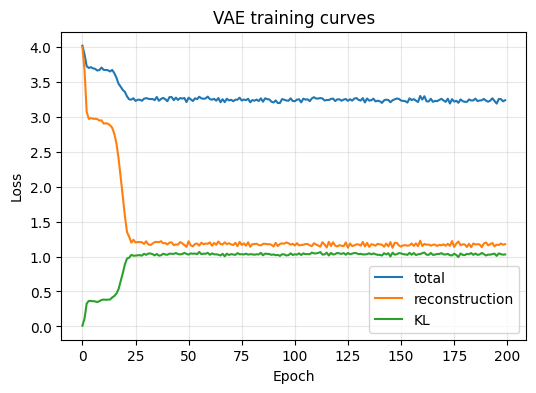

In [10]:
plt.figure(figsize=(6, 4))
plt.plot(vae_history['loss'], label='total')
plt.plot(vae_history['recon'], label='reconstruction')
plt.plot(vae_history['kl'], label='KL')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('VAE training curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

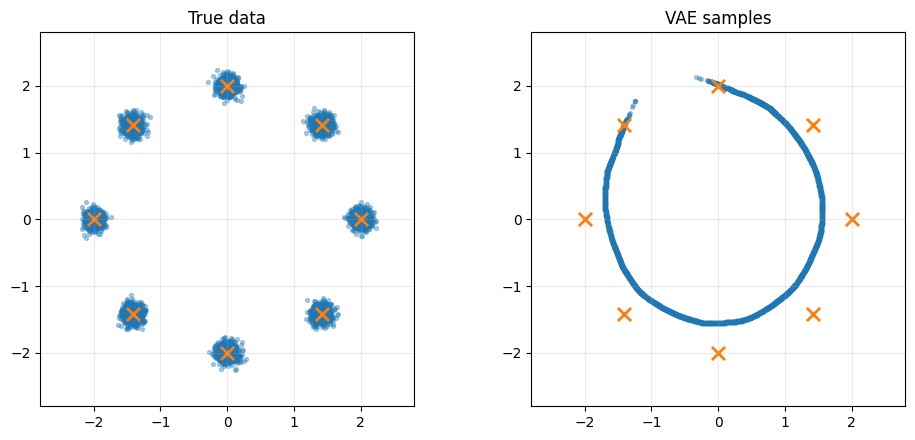

model | cov_trace | variance_ratio | radial_mean | radial_std | nearest_center_mse | covered_components | min_component_count | max_component_count
--- | --- | --- | --- | --- | --- | --- | --- | ---
True data | 4.0072 | 1.0000 | 2.0000 | 0.0795 | 0.0128 | 8 | 579 | 670
VAE | 2.7807 | 0.6939 | 1.6617 | 0.1448 | 0.3066 | 8 | 457 | 789


In [11]:
vae_samples = sample_vae(vae, n_samples=n_generate, latent_dim=vae_latent_dim, device=device)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
plot_2d_samples(x_train_np, centers_np, title='True data', ax=axes[0])
plot_2d_samples(vae_samples, centers_np, title='VAE samples', ax=axes[1])
plt.tight_layout()
plt.show()

vae_summary = sample_summary(vae_samples, centers_np, true_samples=x_train_np, name='VAE')
print_summary_table([true_summary, vae_summary])

# Step 4. DDPM implementation

The DDPM implementation follows the usual toy DDPM recipe:

1. sample a timestep $t$;
2. directly sample the noisy point

$$
x_t = \sqrt{\bar{a_t}}x_0 + \sqrt{1 - \bar{a_t}}\epsilon;
$$
where $$\bar{a_t} = \prod_{i=1}^t a_i$$
3. train a neural network $\epsilon_\theta(x_t,t)$ to predict the noise $\epsilon$;
4. generate new points by starting from Gaussian noise and repeatedly applying the learned denoising transition.

The neural network used here is a small MLP.  You will find that in many applications of DDPM for images, the neural network used is a U-Net (a kind of CNN).  100 diffusion steps are used here.

### **Exercise 2**

In the code below, can you identify what is used for the forward process?

<details><summary><a>Answer (click)</a></summary>
self.betas = torch.linspace(beta_start, beta_end, timesteps) which corresponds to $\beta_t^2$ in our notation.  This corresponds to a linear in time schedule.
</details>


In [12]:
# map noise levels to a sinusoidal embedding for the MLP to interpret.
def sinusoidal_embedding(timesteps, dim):
    # Create sinusoidal timestep embeddings.
    half_dim = dim // 2
    exponent = -math.log(10000) * torch.arange(half_dim, device=timesteps.device) / max(half_dim - 1, 1)
    freqs = torch.exp(exponent)
    args = timesteps.float()[:, None] * freqs[None, :]
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
    if dim % 2 == 1:
        emb = F.pad(emb, (0, 1))
    return emb


class NoisePredictor(nn.Module):
    def __init__(self, data_dim=2, time_dim=32, hidden_dim=128):
        super().__init__()
        self.time_dim = time_dim
        self.net = nn.Sequential(
            nn.Linear(data_dim + time_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, data_dim),
        )

    def forward(self, x, t):
        t_emb = sinusoidal_embedding(t, self.time_dim)
        return self.net(torch.cat([x, t_emb], dim=-1))

In [13]:
class GaussianDiffusion2D:
    def __init__(self, timesteps=100, beta_start=1e-4, beta_end=0.05, device='cpu'):
        self.timesteps = timesteps
        self.device = device

        self.betas = torch.linspace(beta_start, beta_end, timesteps, device=device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.0)

        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)
        self.sqrt_recip_alphas = torch.sqrt(1.0 / self.alphas)

        self.posterior_variance = (
            self.betas * (1.0 - self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)
        )

    def extract(self, a, t, x_shape):
        out = a.gather(-1, t)
        return out.reshape(t.shape[0], *((1,) * (len(x_shape) - 1)))

    def q_sample(self, x_start, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x_start)
        sqrt_alpha_bar = self.extract(self.sqrt_alphas_cumprod, t, x_start.shape)
        sqrt_one_minus_alpha_bar = self.extract(self.sqrt_one_minus_alphas_cumprod, t, x_start.shape)
        return sqrt_alpha_bar * x_start + sqrt_one_minus_alpha_bar * noise

    def training_loss(self, model, x_start):
        batch_size = x_start.shape[0]
        t = torch.randint(0, self.timesteps, (batch_size,), device=x_start.device).long()
        noise = torch.randn_like(x_start)
        x_noisy = self.q_sample(x_start, t, noise=noise)
        predicted_noise = model(x_noisy, t)
        return F.mse_loss(predicted_noise, noise)

    @torch.no_grad()
    def p_sample(self, model, x, t_index):
        batch_size = x.shape[0]
        t = torch.full((batch_size,), t_index, device=x.device, dtype=torch.long)
        beta_t = self.extract(self.betas, t, x.shape)
        sqrt_one_minus_alpha_bar_t = self.extract(self.sqrt_one_minus_alphas_cumprod, t, x.shape)
        sqrt_recip_alpha_t = self.extract(self.sqrt_recip_alphas, t, x.shape)

        model_mean = sqrt_recip_alpha_t * (x - beta_t * model(x, t) / sqrt_one_minus_alpha_bar_t)

        if t_index == 0:
            return model_mean
        posterior_variance_t = self.extract(self.posterior_variance, t, x.shape)
        noise = torch.randn_like(x)
        return model_mean + torch.sqrt(posterior_variance_t) * noise

    @torch.no_grad()
    def sample(self, model, n_samples=5000, data_dim=2, device='cpu'):
        model.eval()
        x = torch.randn(n_samples, data_dim, device=device)
        for t_index in tqdm(reversed(range(self.timesteps)), total=self.timesteps, desc='DDPM sampling'):
            x = self.p_sample(model, x, t_index)
        return x.detach().cpu()

### **Exercise 3**

Why does the DDPM sample more slowly than the VAE?

<details><summary><a>Answer (click)</a></summary>
The VAE generates a sample with one decoder pass. The DDPM starts from Gaussian noise and applies many denoising steps. In this notebook we use 100 steps, so generation requires roughly 100 neural-network calls instead of one.
</details>




In [14]:
def train_ddpm(model, diffusion, train_loader, epochs=300, lr=1e-3, device='cpu'):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = []

    for epoch in tqdm(range(epochs), desc='Training DDPM'):
        model.train()
        loss_sum = 0.0
        n_seen = 0
        for (x,) in train_loader:
            x = x.to(device)
            optimizer.zero_grad()
            loss = diffusion.training_loss(model, x)
            loss.backward()
            optimizer.step()

            batch_n = x.shape[0]
            loss_sum += loss.item() * batch_n
            n_seen += batch_n

        history.append(loss_sum / n_seen)

    return model, optimizer, history

In [15]:
# DDPM training settings
# These are deliberately small enough for a fast run
ddpm_timesteps = 100
ddpm_hidden_dim = 128
ddpm_epochs = 300

noise_model = NoisePredictor(data_dim=2, time_dim=32, hidden_dim=ddpm_hidden_dim)
diffusion = GaussianDiffusion2D(
    timesteps=ddpm_timesteps,
    beta_start=1e-4,
    beta_end=0.05,
    device=device,
)

print(noise_model)
print('Number of trainable parameters:', count_parameters(noise_model))

# Run this cell to train the DDPM.
noise_model, ddpm_optimizer, ddpm_history = train_ddpm(
    noise_model,
    diffusion,
    train_loader,
    epochs=ddpm_epochs,
    lr=1e-3,
    device=device,
)


NoisePredictor(
  (net): Sequential(
    (0): Linear(in_features=34, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): SiLU()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): SiLU()
    (6): Linear(in_features=128, out_features=2, bias=True)
  )
)
Number of trainable parameters: 37762


Training DDPM:   0%|          | 0/300 [00:00<?, ?it/s]

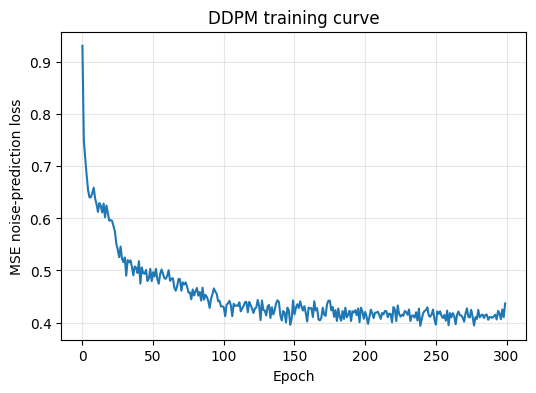

In [16]:
plt.figure(figsize=(6, 4))
plt.plot(ddpm_history)
plt.xlabel('Epoch')
plt.ylabel('MSE noise-prediction loss')
plt.title('DDPM training curve')
plt.grid(True, alpha=0.3)
plt.show()

DDPM sampling:   0%|          | 0/100 [00:00<?, ?it/s]

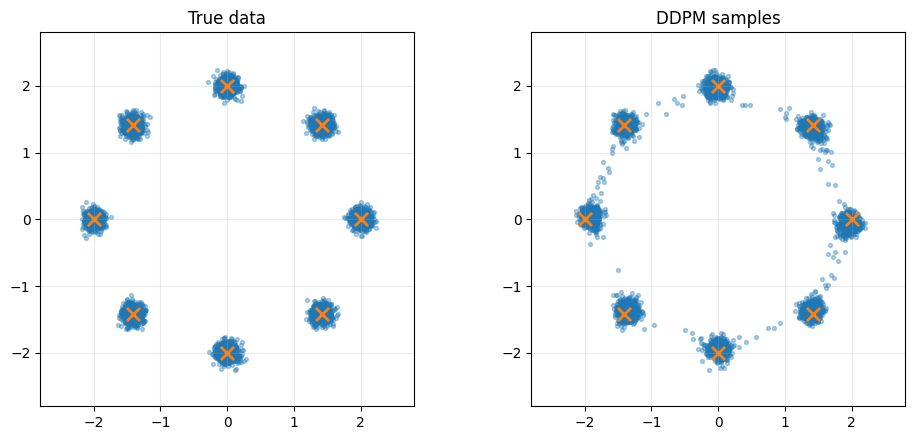

model | cov_trace | variance_ratio | radial_mean | radial_std | nearest_center_mse | covered_components | min_component_count | max_component_count
--- | --- | --- | --- | --- | --- | --- | --- | ---
True data | 4.0072 | 1.0000 | 2.0000 | 0.0795 | 0.0128 | 8 | 579 | 670
DDPM | 3.8201 | 0.9533 | 1.9536 | 0.0808 | 0.0203 | 8 | 550 | 690


In [17]:
ddpm_samples = diffusion.sample(noise_model, n_samples=n_generate, data_dim=2, device=device)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
plot_2d_samples(x_train_np, centers_np, title='True data', ax=axes[0])
plot_2d_samples(ddpm_samples, centers_np, title='DDPM samples', ax=axes[1])
plt.tight_layout()
plt.show()

ddpm_summary = sample_summary(ddpm_samples, centers_np, true_samples=x_train_np, name='DDPM')
print_summary_table([true_summary, ddpm_summary])

# Step 5. Compare VAE and DDPM samples

Now compare the true data, VAE samples, and DDPM samples on the metrics from earlier.

The key diagnostic is the **variance ratio**:

$$
\text{variance ratio} = \frac{\operatorname{tr}(\operatorname{Cov}(\text{generated samples}))}{\operatorname{tr}(\operatorname{Cov}(\text{true samples}))}.
$$

A ratio below 1 means that the generated samples have less total variance than the true data.

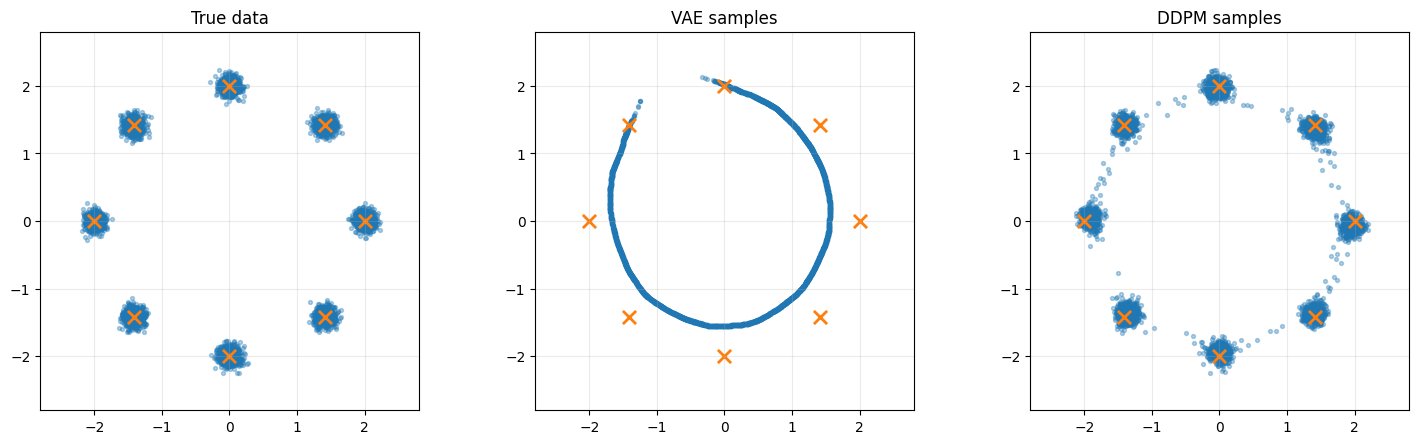

model | cov_trace | variance_ratio | radial_mean | radial_std | nearest_center_mse | covered_components | min_component_count | max_component_count
--- | --- | --- | --- | --- | --- | --- | --- | ---
True data | 4.0072 | 1.0000 | 2.0000 | 0.0795 | 0.0128 | 8 | 579 | 670
VAE | 2.7807 | 0.6939 | 1.6617 | 0.1448 | 0.3066 | 8 | 457 | 789
DDPM | 3.8201 | 0.9533 | 1.9536 | 0.0808 | 0.0203 | 8 | 550 | 690


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
plot_2d_samples(x_train_np, centers_np, title='True data', ax=axes[0])
plot_2d_samples(vae_samples, centers_np, title='VAE samples', ax=axes[1])
plot_2d_samples(ddpm_samples, centers_np, title='DDPM samples', ax=axes[2])
plt.tight_layout()
plt.show()

summaries = [true_summary, vae_summary, ddpm_summary]
print_summary_table(summaries)

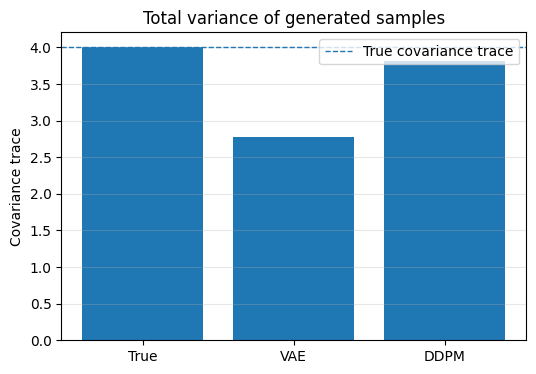

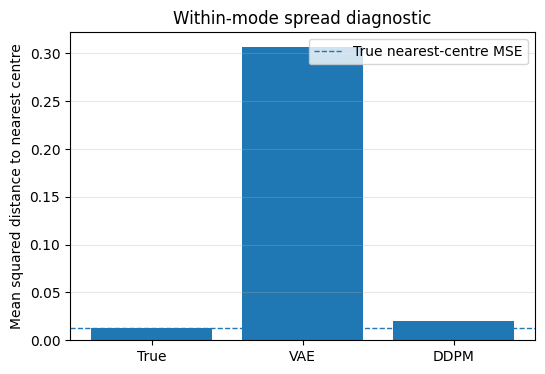

In [19]:
labels = ['True', 'VAE', 'DDPM']
cov_traces = [true_summary['cov_trace'], vae_summary['cov_trace'], ddpm_summary['cov_trace']]
nearest_mses = [true_summary['nearest_center_mse'], vae_summary['nearest_center_mse'], ddpm_summary['nearest_center_mse']]

plt.figure(figsize=(6, 4))
plt.bar(labels, cov_traces)
plt.axhline(true_summary['cov_trace'], linestyle='--', linewidth=1, label='True covariance trace')
plt.ylabel('Covariance trace')
plt.title('Total variance of generated samples')
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(labels, nearest_mses)
plt.axhline(true_summary['nearest_center_mse'], linestyle='--', linewidth=1, label='True nearest-centre MSE')
plt.ylabel('Mean squared distance to nearest centre')
plt.title('Within-mode spread diagnostic')
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.show()

In [20]:
vae_ratio = vae_summary['variance_ratio']
ddpm_ratio = ddpm_summary['variance_ratio']

print(f"VAE variance ratio:  {vae_ratio:.3f}")
print(f"DDPM variance ratio: {ddpm_ratio:.3f}")

if vae_ratio < ddpm_ratio:
    print('In this run, the VAE is more under-dispersed than the DDPM.')
else:
    print('In this run, the VAE did not underestimate variance more than the DDPM.')
    print('Try increasing beta_vae, reducing vae_latent_dim, or training the DDPM for longer.')

VAE variance ratio:  0.694
DDPM variance ratio: 0.953
In this run, the VAE is more under-dispersed than the DDPM.


### **Important**

These results should be taken only as a demonstration, and should not be taken to mean  that VAEs **always** underestimate variance. A more expressive VAE, a mixture prior, a normalising-flow decoder, or better-tuned likelihood can reduce or remove this effect.

### **Exercise 4**

Aside from the size of the latent dimension in the VAE and the fact that the DDPM constructs a sequence of latent variables, what might be another reason why the DDPM outperforms the VAE here?

<details><summary><a>Answer (click)</a></summary>
The VAE has far fewer trainable parameters than the DDPM, so it is much less expressive.
</details>


### **Further Exercises**

Try changing one the following settings at a time to determine the impact on performance.

1. Set `vae_latent_dim = 2`. Does the VAE recover more variance? Yes, increasing VAE's latent dimension from 1 to 2 provides more capacity to the model. This larger latent space allows the VAE to represent the multimodal distribution more effectively, leading to a better recovery of the true data's variance and potentially reducing under-dispersion.

2. Set `beta_vae = 1.0`. Does reducing KL pressure increase sample spread? Yes, reducing beta_vae from 2.0 to 1.0 decreases the weight of the Kullback-Leibler (KL) divergence term in the VAE loss. This means less penalty for the approximate posterior q(z|x) to deviate from the prior p(z). This reduced pressure on the latent space can lead to a more diverse and spread-out set of generated samples, thereby increasing the sample spread.

3. Increase `ddpm_timesteps` from 100 to 200. Does DDPM sampling improve? Yes, increasing the number of diffusion timesteps generally improves DDPM sampling quality. More timesteps mean smaller, more granular denoising steps during the reverse process. This allows the model to reconstruct the original data more accurately and smoothly, leading to samples that better match the true data distribution.

4. Reduce `ddpm_epochs`. How little training is enough to cover all 8 modes? 75 for clusters to become distinguishable around the modes.

5. Increase `component_std` from 0.08 to 0.15. Does a wider target distribution make the variance comparison easier or harder? Easier, increasing the component_std means the individual Gaussian components of the target distribution are wider and more spread out. This might make the variance comparison easier, as the difference between a model that genuinely captures this wider spread (like a well-performing DDPM) and one that still under-disperses (like a constrained VAE) could become more pronounced. The VAE might still struggle to capture the full extent of the widened modes, making its under-dispersion more apparent.


